In [10]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [11]:
BASE_DIR = Path.cwd().parent
DATA_PATH = ( BASE_DIR / "data" / "processed" / "cleaned_network_data.csv" ) 
df = pd.read_csv(DATA_PATH) 
print(df.shape) 
df.head()

(257673, 51)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_srv_dst,is_sm_ips_ports,attack_cat,label,dataset,total_bytes,total_packets,bytes_per_packet,traffic_direction_ratio,packet_direction_ratio
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,2,0,Normal,0,train,496,2,165.333333,496.0,2.0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,2,0,Normal,0,train,1762,2,587.333333,1762.0,2.0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,3,0,Normal,0,train,1068,2,356.000000,1068.0,2.0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,3,0,Normal,0,train,900,2,300.000000,900.0,2.0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,3,0,Normal,0,train,2126,2,708.666667,2126.0,2.0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 51 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       257673 non-null  int64  
 1   dur                      257673 non-null  float64
 2   proto                    257673 non-null  str    
 3   service                  257673 non-null  str    
 4   state                    257673 non-null  str    
 5   spkts                    257673 non-null  int64  
 6   dpkts                    257673 non-null  int64  
 7   sbytes                   257673 non-null  int64  
 8   dbytes                   257673 non-null  int64  
 9   rate                     257673 non-null  float64
 10  sttl                     257673 non-null  int64  
 11  dttl                     257673 non-null  int64  
 12  sload                    257673 non-null  float64
 13  dload                    257673 non-null  float64
 14  sloss          

In [13]:
df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label,total_bytes,total_packets,bytes_per_packet,traffic_direction_ratio,packet_direction_ratio
count,257673.000000,257673.000000,257673.000000,257673.000000,2.576730e+05,2.576730e+05,2.576730e+05,257673.000000,257673.000000,2.576730e+05,...,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,2.576730e+05,257673.000000,257673.000000,257673.000000,257673.000000
mean,72811.823858,1.246715,19.777144,18.514703,8.572952e+03,1.438729e+04,9.125391e+04,180.000931,84.754957,7.060869e+07,...,0.132005,6.800045,9.121049,0.014274,0.639077,2.296024e+04,38.291847,152.497083,214.344107,2.187114
std,48929.917641,5.974305,135.947152,111.985965,1.737739e+05,1.461993e+05,1.603446e+05,102.488268,112.762131,1.857313e+08,...,0.681854,8.396266,10.874752,0.118618,0.480269,2.282063e+05,206.617801,206.277411,1508.839065,7.011869
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,0.000000,1.000000,1.000000,0.000000,0.000000,2.400000e+01,1.000000,12.000000,0.001974,0.002497
25%,32210.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.078928e+01,62.000000,0.000000,1.231800e+04,...,0.000000,2.000000,2.000000,0.000000,0.000000,1.140000e+02,2.000000,38.000000,0.936170,0.960630
50%,64419.000000,0.004285,4.000000,2.000000,5.280000e+02,1.780000e+02,2.955665e+03,254.000000,29.000000,7.439423e+05,...,0.000000,3.000000,4.000000,0.000000,1.000000,8.320000e+02,8.000000,66.666667,21.007059,1.684211
75%,110923.000000,0.685777,12.000000,10.000000,1.362000e+03,1.064000e+03,1.250000e+05,254.000000,252.000000,8.000000e+07,...,0.000000,8.000000,11.000000,0.000000,1.000000,3.084000e+03,22.000000,130.440678,114.000000,2.000000
max,175341.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,30.000000,60.000000,62.000000,1.000000,1.000000,1.472823e+07,12660.000000,1284.857143,54944.000000,512.000000


In [14]:
df["label"].value_counts(normalize=True)*100

label
1    63.907744
0    36.092256
Name: proportion, dtype: float64

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
X = df.drop(
    columns=[
        "id",
        "dataset",
        "attack_cat",
        "label"
    ]
)

y = df["attack_cat"]

In [17]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [18]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 47 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   dur                      257673 non-null  float64
 1   proto                    257673 non-null  str    
 2   service                  257673 non-null  str    
 3   state                    257673 non-null  str    
 4   spkts                    257673 non-null  int64  
 5   dpkts                    257673 non-null  int64  
 6   sbytes                   257673 non-null  int64  
 7   dbytes                   257673 non-null  int64  
 8   rate                     257673 non-null  float64
 9   sttl                     257673 non-null  int64  
 10  dttl                     257673 non-null  int64  
 11  sload                    257673 non-null  float64
 12  dload                    257673 non-null  float64
 13  sloss                    257673 non-null  int64  
 14  dloss          

In [19]:
categorical_columns = X.select_dtypes(include=["object"]).columns

print("Categorical Features:")
print(categorical_columns.tolist())

Categorical Features:
['proto', 'service', 'state']


C:\Users\gurle\AppData\Local\Temp\ipykernel_19780\3773938679.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns


In [20]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

In [21]:
print(f"Total Features After Encoding: {X.shape[1]}")

X.head()

Total Features After Encoding: 198


,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,state_CLO,state_CON,state_ECO,state_FIN,state_INT,state_PAR,state_REQ,state_RST,state_URN,state_no
0,0.000011,2,0,496,0,90909.0902,254,0,180363632.0,0.0,...,False,False,False,False,True,False,False,False,False,False
1,0.000008,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,...,False,False,False,False,True,False,False,False,False,False
2,0.000005,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,...,False,False,False,False,True,False,False,False,False,False
3,0.000006,2,0,900,0,166666.6608,254,0,600000000.0,0.0,...,False,False,False,False,True,False,False,False,False,False
4,0.000010,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,...,False,False,False,False,True,False,False,False,False,False


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

print("\nTraining Labels")
print(pd.Series(y_train).value_counts())

print("\nTesting Labels")
print(pd.Series(y_test).value_counts())

Training Set : (206138, 198)
Testing Set  : (51535, 198)

Training Labels
6    74400
5    47097
3    35620
4    19397
2    13082
7    11189
0     2142
1     1863
8     1209
9      139
Name: count, dtype: int64

Testing Labels
6    18600
5    11774
3     8905
4     4849
2     3271
7     2798
0      535
1      466
8      302
9       35
Name: count, dtype: int64


In [15]:
sample_df = X_test.head(100)

sample_df.to_csv(
    BASE_DIR / "sample_data" / "sample_network_traffic.csv",
    index=False
)

In [24]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [17]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )

}

In [18]:
results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
    y_test,
    predictions,
    average="weighted"
    )

    recall = recall_score(
    y_test,
    predictions,
    average="weighted"
    )

    f1 = f1_score(
    y_test,
    predictions,
    average="weighted"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

print("\nTraining Complete!")


Training Logistic Regression...


c:\Users\gurle\Downloads\CyberSight-AI\CyberAI\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\gurle\Downloads\CyberSight-AI\CyberAI\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Training Decision Tree...

Training Random Forest...

Training XGBoost...

Training Complete!


In [19]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.828505,0.829764,0.828505,0.820340
3,XGBoost,0.833822,0.833902,0.833822,0.813952
1,Decision Tree,0.810672,0.811662,0.810672,0.807471
0,Logistic Regression,0.556651,0.409188,0.556651,0.429063


In [20]:
comparison_df = results_df.copy()

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.5567,0.4092,0.5567,0.4291
1,Decision Tree,0.8107,0.8117,0.8107,0.8075
2,Random Forest,0.8285,0.8298,0.8285,0.8203
3,XGBoost,0.8338,0.8339,0.8338,0.8140


In [23]:
import time

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [24]:
top_models = {
    "Random Forest": models["Random Forest"],
    "XGBoost": models["XGBoost"]
}

evaluation_results = []

for name, model in top_models.items():

    print(f"{name}")

    # -----------------------
    # Training Time
    # -----------------------

    start_train = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_train

    # -----------------------
    # Prediction Time
    # -----------------------

    start_pred = time.time()

    predictions = model.predict(X_test)

    prediction_time = time.time() - start_pred

    

    # -----------------------
    # Metrics
    # -----------------------

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
    y_test,
    predictions,
    average="weighted"
    )

    recall = recall_score(
    y_test,
    predictions,
    average="weighted"
    )

    f1 = f1_score(
    y_test,
    predictions,
    average="weighted"
    )

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (s)": train_time,
        "Prediction Time (s)": prediction_time
    })

    print("\nClassification Report\n")
    print(classification_report(y_test, predictions))

    print(f"Training Time : {train_time:.2f} seconds")

    print(f"Prediction Time : {prediction_time:.4f} seconds")

    print("\n")

Random Forest

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.13      0.23       535
           1       0.83      0.11      0.20       466
           2       0.33      0.24      0.28      3271
           3       0.64      0.82      0.72      8905
           4       0.70      0.63      0.66      4849
           5       1.00      0.98      0.99     11774
           6       0.92      0.94      0.93     18600
           7       0.92      0.77      0.84      2798
           8       0.66      0.67      0.67       302
           9       0.59      0.37      0.46        35

    accuracy                           0.83     51535
   macro avg       0.76      0.57      0.60     51535
weighted avg       0.83      0.83      0.82     51535

Training Time : 55.66 seconds
Prediction Time : 1.7025 seconds


XGBoost

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.12      0.22       5

In [25]:
evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Random Forest,0.828505,0.829764,0.828505,0.820340,55.659292,1.702511
1,XGBoost,0.833822,0.833902,0.833822,0.813952,63.023154,0.582052


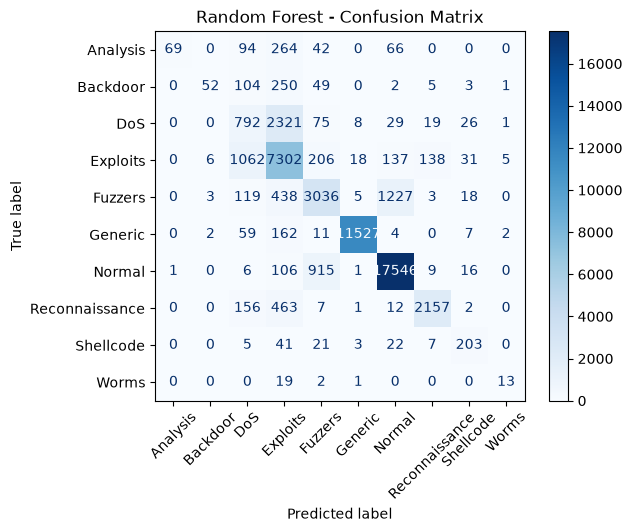

<Figure size 640x480 with 0 Axes>

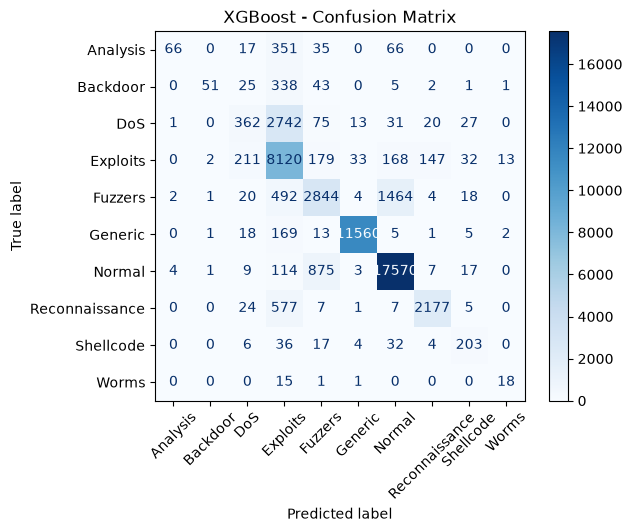

<Figure size 640x480 with 0 Axes>

In [26]:
for name, model in top_models.items():

    predictions = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    xticks_rotation=45
)

    plt.title(f"{name} - Confusion Matrix")

    plt.show()
    plt.savefig("../images/modelsconfusionmatrix.png", dpi=300, bbox_inches="tight")

In [27]:
from sklearn.model_selection import RandomizedSearchCV

In [28]:
param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [None, 10, 20, 30, 40],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"]
}

In [29]:
rf = RandomForestClassifier(
    random_state=42
)

random_search = RandomizedSearchCV(

    estimator=rf,

    param_distributions=param_grid,

    n_iter=20,

    cv=5,

    scoring="f1_weighted",

    random_state=42,

    n_jobs=-1,

    verbose=2

)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function

In [30]:
print("Best Parameters:\n")

print(random_search.best_params_)

Best Parameters:

{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}


In [31]:
print("Best Cross Validation F1 Score:")

print(random_search.best_score_)

Best Cross Validation F1 Score:
0.8181075357787023


In [32]:
best_rf = random_search.best_estimator_

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [31]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [32]:
final_predictions = best_rf.predict(X_test)


In [34]:
print("Accuracy :", accuracy_score(y_test, final_predictions))

print(
    "Precision:",
    precision_score(
        y_test,
        final_predictions,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        final_predictions,
        average="weighted"
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        final_predictions,
        average="weighted"
    )
)


Accuracy : 0.8266032793247308
Precision: 0.827004934465746
Recall: 0.8266032793247308
F1 Score: 0.8171590610385898


In [35]:
from sklearn.metrics import classification_report
import pandas as pd

rf_report = classification_report(
    y_test,
    final_predictions,
    target_names=label_encoder.classes_,
    output_dict=True
)

attack_f1 = pd.DataFrame({

    "Attack Category": label_encoder.classes_,

    "F1 Score": [

        rf_report[cls]["f1-score"]

        for cls in label_encoder.classes_

    ]

})

attack_f1["F1 Score"] = attack_f1["F1 Score"].round(3)

attack_f1 = attack_f1.sort_values(
    by="F1 Score",
    ascending=False
)

attack_f1.to_csv(
    "attack_category_f1.csv",
    index=False
)

attack_f1

,Attack Category,F1 Score
5,Generic,0.987
6,Normal,0.930
7,Reconnaissance,0.842
3,Exploits,0.720
8,Shellcode,0.656
4,Fuzzers,0.651
9,Worms,0.392
2,DoS,0.264
0,Analysis,0.193
1,Backdoor,0.183


In [36]:
from xgboost import XGBClassifier

xgb = XGBClassifier(

    objective="multi:softprob",

    num_class=len(label_encoder.classes_),

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1

)
param_grid = {

    "n_estimators": randint(100,300),

    "max_depth": randint(3,7),

    "learning_rate":[0.03,0.05,0.1],

    "subsample":[0.8,1.0],

    "colsample_bytree":[0.8,1.0],

    "min_child_weight":[1,3]

}
search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_grid,

    n_iter=10,

    cv=3,

    scoring="f1_weighted",

    random_state=42,

    n_jobs=-1,

    verbose=2

)
search.fit(X_train, y_train)
best_xgb = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [37]:
print("Best XGBoost Parameters:\n")

print(search.best_params_)

print("\nBest Cross Validation Weighted F1:")

print(search.best_score_)

Best XGBoost Parameters:

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 230, 'subsample': 0.8}

Best Cross Validation Weighted F1:
0.813678604709223


In [38]:
best_xgb = search.best_estimator_

best_xgb.fit(X_train, y_train)

xgb_predictions = best_xgb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, xgb_predictions))

print(
    "Precision:",
    precision_score(
        y_test,
        xgb_predictions,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        xgb_predictions,
        average="weighted"
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        xgb_predictions,
        average="weighted"
    )
)

Accuracy : 0.8326768215775686
Precision: 0.8311335689336629
Recall: 0.8326768215775686
F1 Score: 0.8125971136760997


In [39]:
comparison = pd.DataFrame({

    "Model": [
        "Random Forest (Tuned)",
        "XGBoost (Tuned)"
    ],

    "Accuracy": [

        accuracy_score(
            y_test,
            final_predictions
        ),

        accuracy_score(
            y_test,
            xgb_predictions
        )

    ],

    "Precision": [

        precision_score(
            y_test,
            final_predictions,
            average="weighted"
        ),

        precision_score(
            y_test,
            xgb_predictions,
            average="weighted"
        )

    ],

    "Recall": [

        recall_score(
            y_test,
            final_predictions,
            average="weighted"
        ),

        recall_score(
            y_test,
            xgb_predictions,
            average="weighted"
        )

    ],

    "Weighted F1": [

        f1_score(
            y_test,
            final_predictions,
            average="weighted"
        ),

        f1_score(
            y_test,
            xgb_predictions,
            average="weighted"
        )

    ]

})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,Weighted F1
0,Random Forest (Tuned),0.8266,0.8270,0.8266,0.8172
1,XGBoost (Tuned),0.8327,0.8311,0.8327,0.8126


<Figure size 1000x800 with 0 Axes>

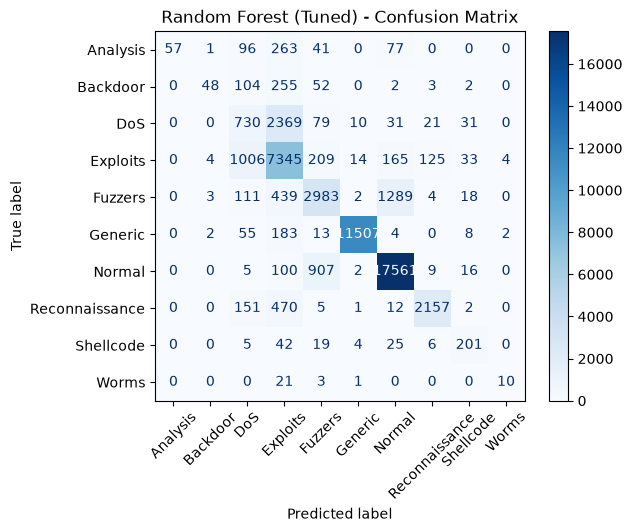

<Figure size 640x480 with 0 Axes>

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

rf_cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Random Forest (Tuned) - Confusion Matrix")
plt.show()
plt.savefig("../images/RFTunedConfusionMatrix.png", dpi=300, bbox_inches="tight")

<Figure size 1000x800 with 0 Axes>

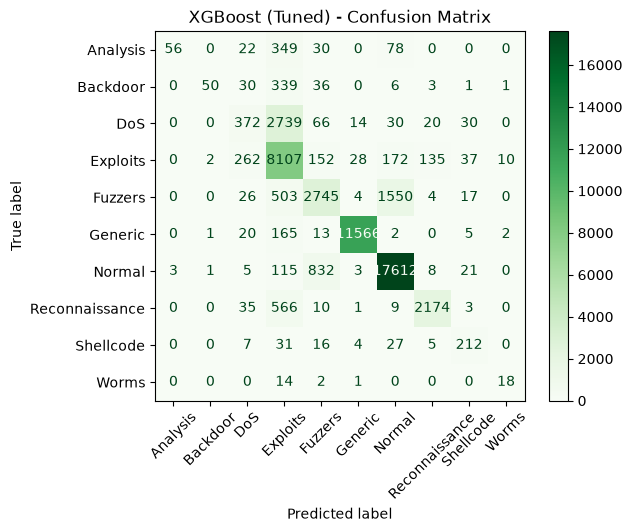

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

xgb_cm = confusion_matrix(y_test, xgb_predictions)

plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Greens",
    xticks_rotation=45,
    values_format="d"
)

plt.title("XGBoost (Tuned) - Confusion Matrix")
plt.show()

In [49]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report\n")

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=label_encoder.classes_
    )
)

Random Forest Classification Report

                precision    recall  f1-score   support

      Analysis       1.00      0.11      0.19       535
      Backdoor       0.83      0.10      0.18       466
           DoS       0.32      0.22      0.26      3271
      Exploits       0.64      0.82      0.72      8905
       Fuzzers       0.69      0.62      0.65      4849
       Generic       1.00      0.98      0.99     11774
        Normal       0.92      0.94      0.93     18600
Reconnaissance       0.93      0.77      0.84      2798
     Shellcode       0.65      0.67      0.66       302
         Worms       0.62      0.29      0.39        35

      accuracy                           0.83     51535
     macro avg       0.76      0.55      0.58     51535
  weighted avg       0.83      0.83      0.82     51535



In [50]:
print("XGBoost Classification Report\n")

print(
    classification_report(
        y_test,
        xgb_predictions,
        target_names=label_encoder.classes_
    )
)

XGBoost Classification Report

                precision    recall  f1-score   support

      Analysis       0.95      0.10      0.19       535
      Backdoor       0.93      0.11      0.19       466
           DoS       0.48      0.11      0.18      3271
      Exploits       0.63      0.91      0.74      8905
       Fuzzers       0.70      0.57      0.63      4849
       Generic       1.00      0.98      0.99     11774
        Normal       0.90      0.95      0.92     18600
Reconnaissance       0.93      0.78      0.84      2798
     Shellcode       0.65      0.70      0.68       302
         Worms       0.58      0.51      0.55        35

      accuracy                           0.83     51535
     macro avg       0.77      0.57      0.59     51535
  weighted avg       0.83      0.83      0.81     51535



In [51]:
from sklearn.metrics import classification_report
import pandas as pd

# Random Forest Report
rf_report = classification_report(
    y_test,
    final_predictions,
    target_names=label_encoder.classes_,
    output_dict=True
)

# XGBoost Report
xgb_report = classification_report(
    y_test,
    xgb_predictions,
    target_names=label_encoder.classes_,
    output_dict=True
)

comparison = pd.DataFrame()

for cls in label_encoder.classes_:

    comparison.loc[cls, "RF Precision"] = rf_report[cls]["precision"]
    comparison.loc[cls, "RF Recall"] = rf_report[cls]["recall"]
    comparison.loc[cls, "RF F1"] = rf_report[cls]["f1-score"]

    comparison.loc[cls, "XGB Precision"] = xgb_report[cls]["precision"]
    comparison.loc[cls, "XGB Recall"] = xgb_report[cls]["recall"]
    comparison.loc[cls, "XGB F1"] = xgb_report[cls]["f1-score"]

comparison = comparison.round(4)

comparison

,RF Precision,RF Recall,RF F1,XGB Precision,XGB Recall,XGB F1
Analysis,1.0000,0.1065,0.1926,0.9492,0.1047,0.1886
Backdoor,0.8276,0.1030,0.1832,0.9259,0.1073,0.1923
DoS,0.3226,0.2232,0.2638,0.4775,0.1137,0.1837
Exploits,0.6394,0.8248,0.7204,0.6271,0.9104,0.7426
Fuzzers,0.6920,0.6152,0.6513,0.7035,0.5661,0.6274
Generic,0.9971,0.9773,0.9871,0.9953,0.9823,0.9888
Normal,0.9163,0.9441,0.9300,0.9038,0.9469,0.9249
Reconnaissance,0.9277,0.7709,0.8421,0.9255,0.7770,0.8448
Shellcode,0.6463,0.6656,0.6558,0.6503,0.7020,0.6752
Worms,0.6250,0.2857,0.3922,0.5806,0.5143,0.5455


In [52]:
comparison["Better Model"] = comparison.apply(
    lambda row: "Random Forest"
    if row["RF F1"] > row["XGB F1"]
    else "XGBoost",
    axis=1
)

comparison

,RF Precision,RF Recall,RF F1,XGB Precision,XGB Recall,XGB F1,Better Model
Analysis,1.0000,0.1065,0.1926,0.9492,0.1047,0.1886,Random Forest
Backdoor,0.8276,0.1030,0.1832,0.9259,0.1073,0.1923,XGBoost
DoS,0.3226,0.2232,0.2638,0.4775,0.1137,0.1837,Random Forest
Exploits,0.6394,0.8248,0.7204,0.6271,0.9104,0.7426,XGBoost
Fuzzers,0.6920,0.6152,0.6513,0.7035,0.5661,0.6274,Random Forest
Generic,0.9971,0.9773,0.9871,0.9953,0.9823,0.9888,XGBoost
Normal,0.9163,0.9441,0.9300,0.9038,0.9469,0.9249,Random Forest
Reconnaissance,0.9277,0.7709,0.8421,0.9255,0.7770,0.8448,XGBoost
Shellcode,0.6463,0.6656,0.6558,0.6503,0.7020,0.6752,XGBoost
Worms,0.6250,0.2857,0.3922,0.5806,0.5143,0.5455,XGBoost


In [53]:
comparison["F1 Difference"] = (
    comparison["XGB F1"] -
    comparison["RF F1"]
).round(4)

comparison

,RF Precision,RF Recall,RF F1,XGB Precision,XGB Recall,XGB F1,Better Model,F1 Difference
Analysis,1.0000,0.1065,0.1926,0.9492,0.1047,0.1886,Random Forest,-0.0040
Backdoor,0.8276,0.1030,0.1832,0.9259,0.1073,0.1923,XGBoost,0.0091
DoS,0.3226,0.2232,0.2638,0.4775,0.1137,0.1837,Random Forest,-0.0801
Exploits,0.6394,0.8248,0.7204,0.6271,0.9104,0.7426,XGBoost,0.0222
Fuzzers,0.6920,0.6152,0.6513,0.7035,0.5661,0.6274,Random Forest,-0.0239
Generic,0.9971,0.9773,0.9871,0.9953,0.9823,0.9888,XGBoost,0.0017
Normal,0.9163,0.9441,0.9300,0.9038,0.9469,0.9249,Random Forest,-0.0051
Reconnaissance,0.9277,0.7709,0.8421,0.9255,0.7770,0.8448,XGBoost,0.0027
Shellcode,0.6463,0.6656,0.6558,0.6503,0.7020,0.6752,XGBoost,0.0194
Worms,0.6250,0.2857,0.3922,0.5806,0.5143,0.5455,XGBoost,0.1533


In [55]:
from sklearn.ensemble import RandomForestClassifier

balanced_rf = RandomForestClassifier(

    n_estimators=500,

    max_depth=None,

    min_samples_split=2,

    min_samples_leaf=2,

    max_features="sqrt",

    class_weight="balanced_subsample",

    random_state=42,

    n_jobs=-1

)

balanced_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced_subsample'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consid

In [56]:
balanced_predictions = balanced_rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, balanced_predictions))

print(
    "Precision:",
    precision_score(
        y_test,
        balanced_predictions,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        balanced_predictions,
        average="weighted"
    )
)

print(
    "Weighted F1:",
    f1_score(
        y_test,
        balanced_predictions,
        average="weighted"
    )
)

Accuracy : 0.7950130978946347
Precision: 0.8500770052240385
Recall: 0.7950130978946347
Weighted F1: 0.8161468644644782


In [57]:
print(
    classification_report(
        y_test,
        balanced_predictions,
        target_names=label_encoder.classes_
    )
)

                precision    recall  f1-score   support

      Analysis       0.09      0.15      0.11       535
      Backdoor       0.03      0.17      0.06       466
           DoS       0.31      0.45      0.37      3271
      Exploits       0.84      0.57      0.68      8905
       Fuzzers       0.66      0.73      0.69      4849
       Generic       1.00      0.98      0.99     11774
        Normal       0.95      0.90      0.92     18600
Reconnaissance       0.89      0.80      0.84      2798
     Shellcode       0.52      0.84      0.64       302
         Worms       0.58      0.60      0.59        35

      accuracy                           0.80     51535
     macro avg       0.59      0.62      0.59     51535
  weighted avg       0.85      0.80      0.82     51535



<Figure size 1000x800 with 0 Axes>

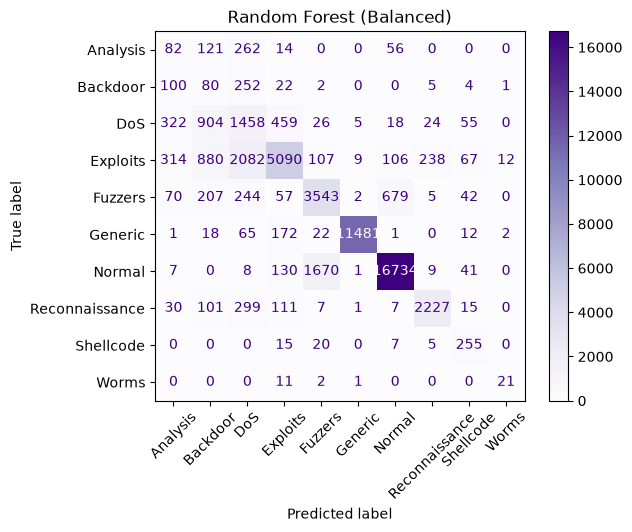

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, balanced_predictions)

plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Purples",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Random Forest (Balanced)")

plt.show()

In [4]:
import pandas as pd

# ==========================================================
# Model Comparison Table
# ==========================================================

model_comparison = pd.DataFrame({

    "Model": [

        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Random Forest (Tuned)",
        "XGBoost (Tuned)",
        "Random Forest (Balanced)"

    ],

    "Accuracy": [

        55.67,
        81.07,
        82.85,
        83.38,
        82.66,
        83.27,
        79.50

    ],

    "Precision": [

        40.92,
        81.17,
        82.98,
        83.39,
        82.70,
        83.11,
        85.01

    ],

    "Recall": [

        55.67,
        81.07,
        82.85,
        83.38,
        82.66,
        83.27,
        79.50

    ],

    "Weighted F1": [

        42.91,
        80.75,
        82.03,
        81.40,
        81.72,
        81.26,
        81.61

    ]

})

# Round values
model_comparison = model_comparison.round(2)

# Display
print(model_comparison)

# Save CSV
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("\nCSV saved successfully as model_comparison.csv")

                      Model  Accuracy  Precision  Recall  Weighted F1
0       Logistic Regression     55.67      40.92   55.67        42.91
1             Decision Tree     81.07      81.17   81.07        80.75
2             Random Forest     82.85      82.98   82.85        82.03
3                   XGBoost     83.38      83.39   83.38        81.40
4     Random Forest (Tuned)     82.66      82.70   82.66        81.72
5           XGBoost (Tuned)     83.27      83.11   83.27        81.26
6  Random Forest (Balanced)     79.50      85.01   79.50        81.61

CSV saved successfully as model_comparison.csv


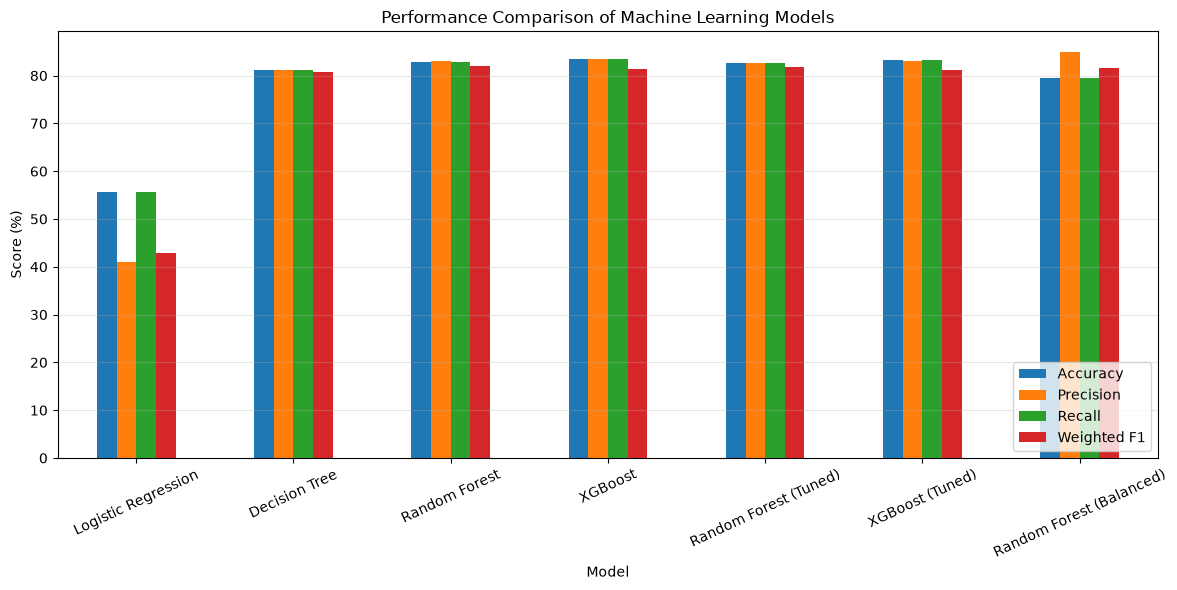

In [5]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "Weighted F1"]

plot_df = model_comparison.set_index("Model")[metrics]

ax = plot_df.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Performance Comparison of Machine Learning Models")

plt.ylabel("Score (%)")

plt.xticks(rotation=25)

plt.grid(axis="y", alpha=0.3)

plt.legend(loc="lower right")

plt.tight_layout()

# Save FIRST
plt.savefig(
    "../images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

# Then display
plt.show()

In [26]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_rf.feature_importances_

})

In [27]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
39,total_bytes,0.064277
3,sbytes,0.056395
41,bytes_per_packet,0.054843
42,traffic_direction_ratio,0.053003
6,sttl,0.046951
37,ct_srv_dst,0.042838
23,smean,0.040623
177,service_dns,0.040429
32,ct_dst_src_ltm,0.040165
27,ct_srv_src,0.036203


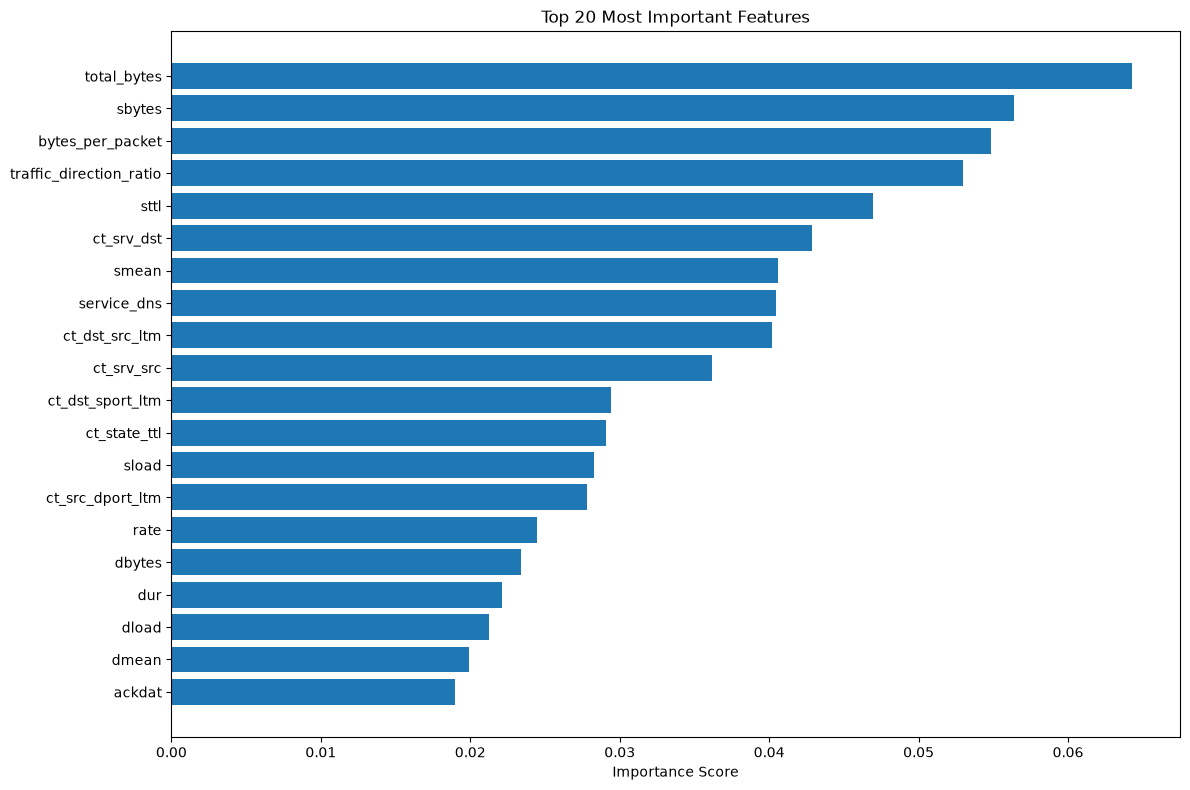

<Figure size 640x480 with 0 Axes>

In [28]:
plt.figure(figsize=(12,8))

top_features = feature_importance.head(20)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 20 Most Important Features")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()
plt.savefig("../images/featureimportance.png", dpi=300, bbox_inches="tight")

In [63]:
feature_importance.to_csv(
    BASE_DIR /
    "models" /
    "feature_importance.csv",
    index=False
)

In [64]:
import joblib

In [65]:
best_model = best_rf

In [66]:
import joblib

joblib.dump(
    best_rf,
    BASE_DIR / "models" / "cybersight_rf_multiclass.pkl"
)

joblib.dump(
    X_train.columns.tolist(),
    BASE_DIR / "models" / "multiclass_features.pkl"
)

joblib.dump(
    label_encoder,
    BASE_DIR / "models" / "attack_label_encoder.pkl"
)

print("Multiclass Random Forest saved successfully.")


Multiclass Random Forest saved successfully.


In [ ]:
from pathlib import Path

dashboard_data_path = (
    BASE_DIR /
    "powerbi" /
    "network_traffic_dashboard.csv"
)

df.to_csv(
    dashboard_data_path,
    index=False
)

print("Dashboard dataset exported successfully!")

Dashboard dataset exported successfully!
